# 7CS033 Assignment Task 4

### Complete the following tasks.

#### You should comment on your code where appropriate. Failing to add comments may result in a mark deduction.

#### You should write any explainations in the report cell if the task explicitly asks for this or if you wish to expand upon your solution.

#### Ensure you have ran your code cell and printed any of the required outputs. If necessary you can use more than one code cell.

# Tasks

## TASK 4.1:  Download the adult_T4 dataset. Apply K-Means and Hierarchical clustering to three optional columns in the dataset. Find the optimum number of clusters for both clustering methods (10%).

## NOTE: You should comment on your code wherever necessary and briefly explain what the code is doing

In [103]:
############# WRITE YOUR CODE IN THIS CELL (IF APPLICABLE)####################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA


from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OrdinalEncoder

from mpl_toolkits.mplot3d import Axes3D



In [121]:
df = pd.read_csv('adult_T4.csv')

d1 = df['age'] #target variable 1
d2 = df['education-num'] #target variable 2
d3 = df['hours-per-week'] #target variable 3

In [122]:
# Select three numerical columns for clustering
# These variables are continuous and suitable for distance-based clustering

X = pd.concat([d1,d2,d3], axis = 1); #get our 3 input variables
#X = X.dropna()


In [123]:
# Remove missing values (clustering cannot handle NaNs)
X = X.dropna()


In [124]:

# Scaling is important because clustering uses distance metrics
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### K-MEANS CLUSTERING

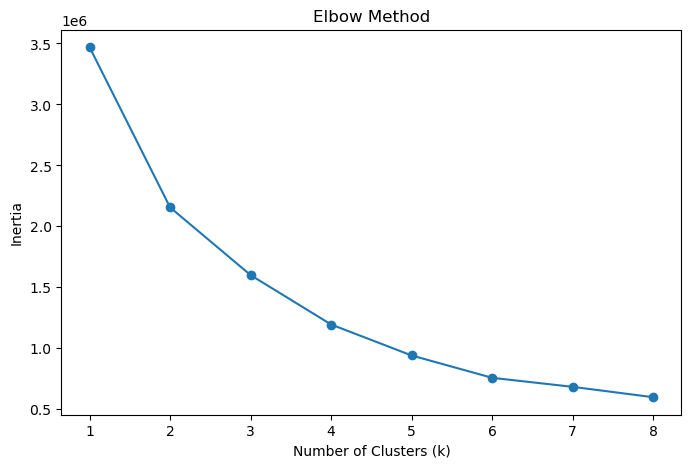

In [125]:

# --- Elbow Method ---
# Used to identify the point where adding more clusters
# does not significantly reduce inertia

inertia = []


for k in range(1, 9):
    km = KMeans(n_clusters = k, random_state = 42)
    km.fit(X)
    inertia.append(km.inertia_)

#plot the elbow curve
plt.figure(figsize=(8,5))
plt.plot(range(1,9), inertia, marker = 'o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

k=2, Silhouette Score=0.37965490443771743
k=3, Silhouette Score=0.323411684363288
k=4, Silhouette Score=0.4024432969339395
k=5, Silhouette Score=0.3843419106780839
k=6, Silhouette Score=0.3775365397877103
k=7, Silhouette Score=0.3367647194464343
k=8, Silhouette Score=0.3486205456416944


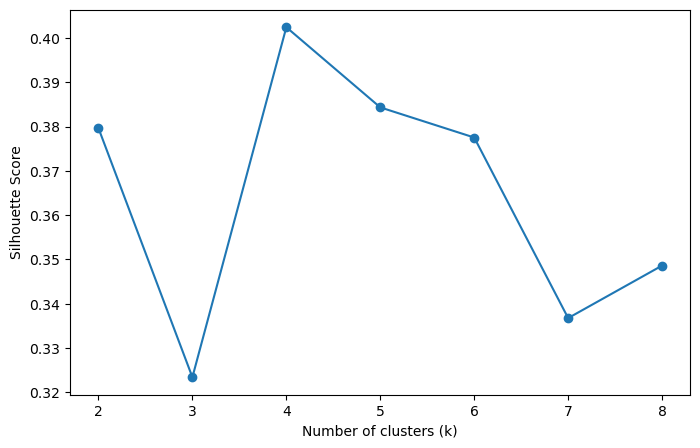

In [126]:
# Silhouette Method 
# Measures how well points fit within their clusters

sil_scores = []

#
for k in range (2, 9):
    km = KMeans(n_clusters = k, random_state = 42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(silhouette_score(X, labels))
    print(f"k={k}, Silhouette Score={score}")


plt.figure(figsize = (8, 5))
plt.plot(range(2,9), sil_scores, marker = 'o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.show()

In [129]:
# Optimal k is the one with highest silhouette score
optimal_k_kmeans = np.argmax(sil_scores) + 2
print("Optimal k for KMeans:", optimal_k_kmeans)

Optimal k for KMeans: 4


In [130]:
# Fit final KMeans model
kmeans = KMeans(n_clusters=optimal_k_kmeans, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)


### HIERARCHICAL CLUSTERING

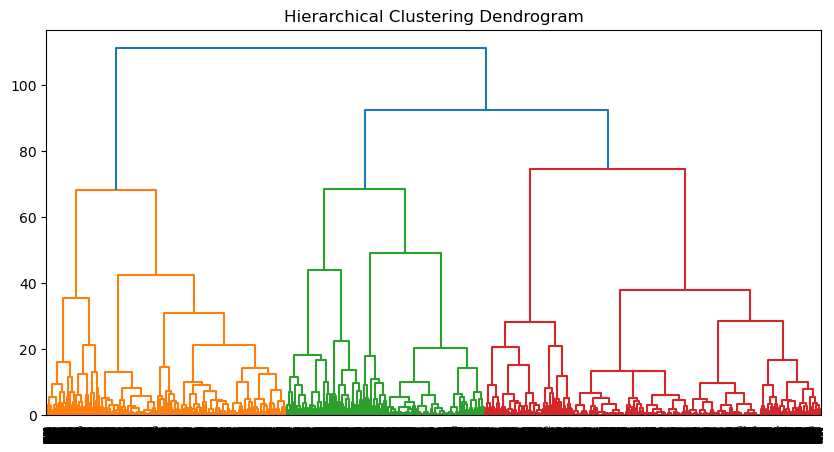

In [131]:

#  Dendrogram 
# Visual representation of hierarchical cluster merging

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

Hierarchical k=2, Silhouette Score=0.2395
Hierarchical k=3, Silhouette Score=0.2379
Hierarchical k=4, Silhouette Score=0.2242
Hierarchical k=5, Silhouette Score=0.2479
Hierarchical k=6, Silhouette Score=0.2795
Hierarchical k=7, Silhouette Score=0.2718
Hierarchical k=8, Silhouette Score=0.2824


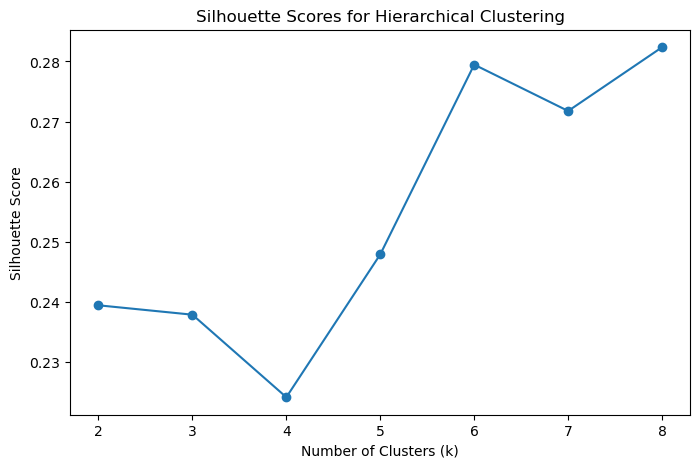

In [133]:
#  Silhouette Method for Hierarchical 

hier_scores = []

for k in range(2, 9):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    hier_scores.append(score)
    print(f"Hierarchical k={k}, Silhouette Score={score:.4f}")

plt.figure(figsize=(8,5))
plt.plot(range(2, 9), hier_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores for Hierarchical Clustering")
plt.show()


In [135]:
optimal_k_hier = np.argmax(hier_scores) + 2
print("Optimal k for Hierarchical:", optimal_k_hier)

Optimal k for Hierarchical: 8


### 3D Scatter Plot for KMeans

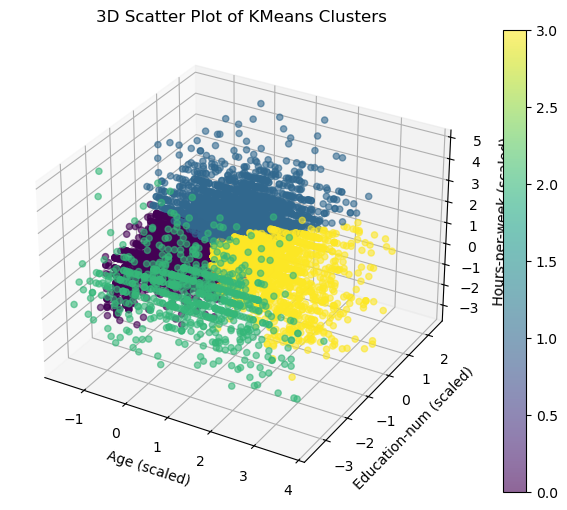

In [149]:
# Create 3D figure
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

centroids = kmeans.cluster_centers_


# Plot clusters
scatter = ax.scatter(
    X_scaled[:, 0],   # age
    X_scaled[:, 1],   # education-num
    X_scaled[:, 2],   # hours-per-week
    c=kmeans_labels,
    cmap='viridis',
    alpha=0.6
)

# Axis labels
ax.set_xlabel("Age (scaled)")
ax.set_ylabel("Education-num (scaled)")
ax.set_zlabel("Hours-per-week (scaled)")
ax.set_title("3D Scatter Plot of KMeans Clusters")

plt.colorbar(scatter)
plt.show()


### 3D Plot for Hierarchical Clustering

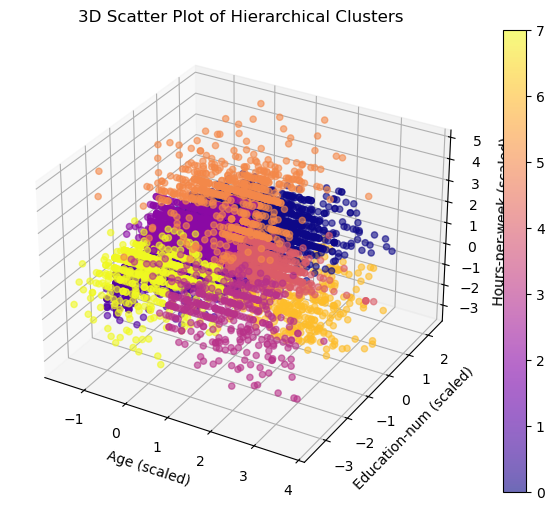

In [147]:
# Fit hierarchical model using optimal k
agg = AgglomerativeClustering(n_clusters=optimal_k_hier)
hier_labels = agg.fit_predict(X_scaled)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    X_scaled[:, 2],
    c=hier_labels,
    cmap='plasma',
    alpha=0.6
)

ax.set_xlabel("Age (scaled)")
ax.set_ylabel("Education-num (scaled)")
ax.set_zlabel("Hours-per-week (scaled)")
ax.set_title("3D Scatter Plot of Hierarchical Clusters")

plt.colorbar(scatter)
plt.show()


## Task 4.2: Apply the PCA method to the dataset and extract the first two principal components (n_components=2). Plot the scatter plot of the dataset's first two components for the two classes of the income column (5%). 

## NOTE 1: You should comment on your code wherever necessary and briefly explain what the code is doing.

## NOTE 2: You need to encode the categorical columns, normalise the dataset, and remove the income column before applying the PCA method. 

In [138]:
# Replace '?' values with NaN
df.replace("?", np.nan, inplace=True)

# Drop rows with missing values
df2 = df.dropna()

In [139]:
#Encode Categorical Variables
encoder = OrdinalEncoder()
categorical_cols = df2.select_dtypes(include='object').columns

df2[categorical_cols] = encoder.fit_transform(df2[categorical_cols])


/var/folders/6b/x27jrjp92kn9r5_84c_ywfhcsgm8y7/T/ipykernel_55423/1630149546.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2[categorical_cols] = encoder.fit_transform(df2[categorical_cols])


In [140]:
# Separate features and target variable
X2 = df2.drop('income', axis=1)
y2 = df2['income']


In [143]:
#Normalise the Dataset

# PCA is affected by scale, so we normalise
scaler = MinMaxScaler()
X2_scaled = scaler.fit_transform(X2)

### Apply PCA

In [144]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X2_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.37235078 0.12949804]


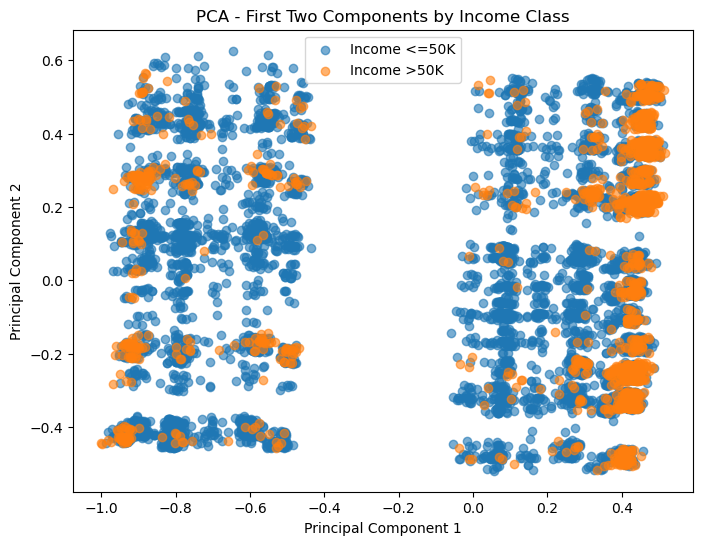

In [145]:
#Plot PCA for the Two Income Classes
# Create masks for the two income classes
class_0 = y2 == 0
class_1 = y2 == 1

plt.figure(figsize=(8,6))

# Plot each class separately
plt.scatter(X_pca[class_0, 0], X_pca[class_0, 1], label="Income <=50K", alpha=0.6)

plt.scatter(X_pca[class_1, 0], X_pca[class_1, 1], label="Income >50K", alpha=0.6)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - First Two Components by Income Class")
plt.legend()
plt.show()